# MEADOW for the angeosperm community data

In [7]:
%load_ext autoreload
%autoreload 2

import os
import sys

import contextily as cx
import numpy as np
import pandas as pd
import torch

from multispecies_resistance.climate import download_climate_layers
from multispecies_resistance.data import SpeciesData
from multispecies_resistance.io import list_pedic_species, load_pedic_species
from multispecies_resistance.train import build_species_graphs, train_model
from multispecies_resistance.viz import plot_multi_edge_resistance, plot_shared_resistance, plot_sites

torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Download and cache BioClim layers (used below by build_species_graphs)
raster_paths = download_climate_layers(
    source='bioclim',
    variables=['bio1', 'bio12'],
    resolution='2.5m',
    cache_dir='~/.cache/multispecies_resistance/climate',
)
len(raster_paths), raster_paths[:2]


(19,
 [PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_1.tif'),
  PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_2.tif')])

In [17]:
community_df = pd.read_csv("../../angiosperm_community_data/site_species_matrix.csv", index_col=0)

coords = community_df[["Latitude", "Longitude"]].values
genos = community_df.iloc[:, 1:-2].values
species_list = [SpeciesData("community", genos, coords)]
print([s.name for s in species_list])


['community']


In [18]:
# Build graphs and train
graphs, stats = build_species_graphs(
    species_list,
    input_graph="../../pedic_grid/hengduan_grid.gml",
    project_to='EPSG:3857',
    coord_order='latlon',
    coords_crs='EPSG:4326',
    raster_paths=raster_paths,
    raster_fill_method='nearest',
    standardize=True,
    support_decay_km=150,

)

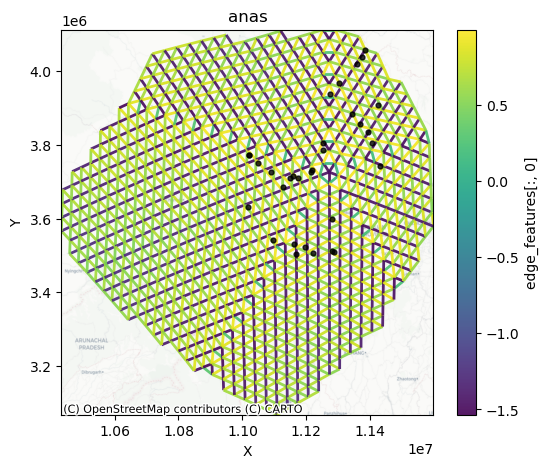

In [36]:
_ = graphs[0].plot(edge_feature_idx=0)

In [19]:
model = train_model(graphs, hidden_dim=32, lr=1e-2, epochs=500, log_every=25, edge_smoothing=0.85)

epoch   25 loss 0.024414 val 0.015514
early stop at epoch 47 val 0.011048 best 0.011022


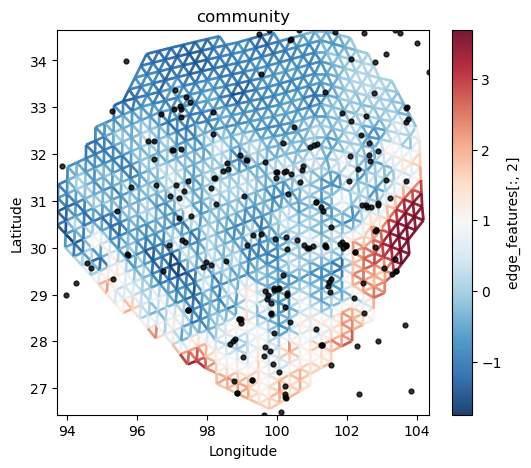

In [31]:
# Visualize edge-feature map for the selected species graph
spidx = 0
ax, gdf = graphs[spidx].plot(
    edge_feature_idx=2,
    basemap=False,
    title=species_list[spidx].name,
    edge_cmap="RdBu_r",
)


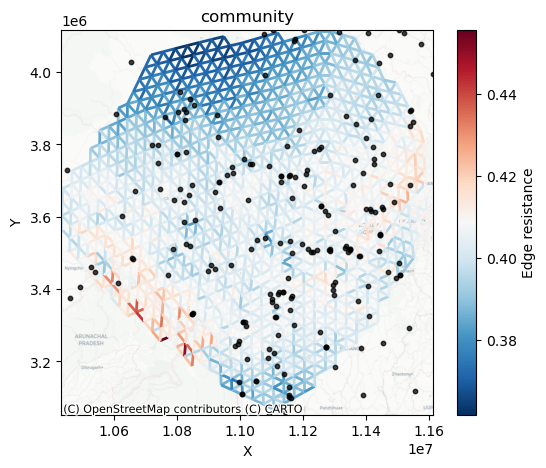

In [39]:
# Multi-species edge resistances (subplot grid)
_ = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    basemap=True,
    show_sites=True,
    explore=True,
    cmap="RdBu_r",
)


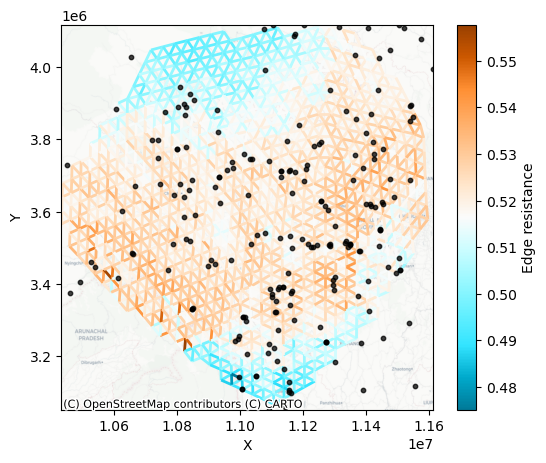

In [32]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #cmap="RdBu",
    #graph_index=1,
    rasterize=False,
    interpolation='kriging',
    grid_size=200,
    explore=True,
    show_sites=True,
)
fig[2]

In [ ]:

# Optional: interactive explore map (all species overlay)
ax, gdf, fmap = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    overlay=True,
    explore=True,
    #cmap=None,
)
fmap


In [ ]:
from multispecies_resistance.cv import choose_edge_smoothing_cv

res = choose_edge_smoothing_cv(graphs)

candidate 1/10 edge_smoothing=0.0000 fold 1/5 (graph fold 0, 1 scored species) step 1/50                                